In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("department_prediction_dataset.csv", keep_default_na=False)

df.head()



,patient_id,age,gender,symptoms,temperature,duration_days,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,oxygen_saturation,pain_level,symptom_severity,chronic_condition,department
0,100001,10,Female,"constipation, abdominal pain",100.1,8,125,80,62,98,5,Moderate,None,Gastroenterology
1,100002,40,Female,"mood swings, stress",98.1,3,107,63,68,100,1,Mild,None,Psychiatry
2,100003,78,Female,"ear pain, hearing loss",99.5,4,126,83,66,98,4,Moderate,Diabetes,ENT
3,100004,40,Male,"rapid heartbeat, chest pain",99.3,10,138,96,83,90,7,Moderate,Hypertension,Cardiology
4,100005,45,Other,"diarrhea, stomach pain",100.2,7,107,67,67,99,5,Moderate,None,Gastroenterology


# Features and Target

In [ ]:
X = df.drop(columns=["patient_id", "department"])

y = df["department"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Define Feature Types

In [ ]:
text_features = ["symptoms"]

categorical_features = [
    "gender",
    "symptom_severity",
    "chronic_condition"
]

numeric_features = [
    "age",
    "temperature",
    "duration_days",
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "heart_rate",
    "oxygen_saturation",
    "pain_level"



]

preprocessor = ColumnTransformer(

    transformers=[

        (
            "text",
            TfidfVectorizer(),
            "symptoms"
        ),

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),

        (
            "num",
            "passthrough",
            numeric_features
        )

    ]

)

# Model Logistic Regression

In [ ]:
logistic_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("classifier", LogisticRegression(
        max_iter=1000
    ))

])

# Train and Predict

In [ ]:
logistic_pipeline.fit(X_train, y_train)

y_pred_lr = logistic_pipeline.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print()

print(classification_report(
    y_test,
    y_pred_lr
))

Accuracy: 0.9925333333333334

                  precision    recall  f1-score   support

      Cardiology       0.97      0.97      0.97      2020
       Dentistry       1.00      1.00      1.00      2012
     Dermatology       1.00      0.99      0.99      1990
             ENT       1.00      1.00      1.00      2001
   Endocrinology       1.00      1.00      1.00      1995
Gastroenterology       1.00      1.00      1.00      2017
General Medicine       0.99      0.99      0.99      2010
      Gynecology       0.99      1.00      1.00      1995
       Neurology       0.98      0.99      0.99      2009
   Ophthalmology       0.99      1.00      1.00      1986
     Orthopedics       0.99      0.99      0.99      1981
      Pediatrics       0.98      0.99      0.99      2010
      Psychiatry       1.00      0.99      1.00      2007
     Pulmonology       0.99      0.99      0.99      1990
         Urology       1.00      1.00      1.00      1977

        accuracy                        

# model Decision Tree

In [ ]:
dt_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("classifier",
     DecisionTreeClassifier(
         random_state=42
     ))

])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print()

print(classification_report(
    y_test,
    y_pred_dt
))

Accuracy: 1.0

                  precision    recall  f1-score   support

      Cardiology       1.00      1.00      1.00      2020
       Dentistry       1.00      1.00      1.00      2012
     Dermatology       1.00      1.00      1.00      1990
             ENT       1.00      1.00      1.00      2001
   Endocrinology       1.00      1.00      1.00      1995
Gastroenterology       1.00      1.00      1.00      2017
General Medicine       1.00      1.00      1.00      2010
      Gynecology       1.00      1.00      1.00      1995
       Neurology       1.00      1.00      1.00      2009
   Ophthalmology       1.00      1.00      1.00      1986
     Orthopedics       1.00      1.00      1.00      1981
      Pediatrics       1.00      1.00      1.00      2010
      Psychiatry       1.00      1.00      1.00      2007
     Pulmonology       1.00      1.00      1.00      1990
         Urology       1.00      1.00      1.00      1977

        accuracy                           1.00     300

# Random Forest

In [ ]:
rf_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("classifier",
     RandomForestClassifier(
         n_estimators=200,
         random_state=42
     ))

])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print()

print(classification_report(
    y_test,
    y_pred_rf
))

Accuracy: 1.0

                  precision    recall  f1-score   support

      Cardiology       1.00      1.00      1.00      2020
       Dentistry       1.00      1.00      1.00      2012
     Dermatology       1.00      1.00      1.00      1990
             ENT       1.00      1.00      1.00      2001
   Endocrinology       1.00      1.00      1.00      1995
Gastroenterology       1.00      1.00      1.00      2017
General Medicine       1.00      1.00      1.00      2010
      Gynecology       1.00      1.00      1.00      1995
       Neurology       1.00      1.00      1.00      2009
   Ophthalmology       1.00      1.00      1.00      1986
     Orthopedics       1.00      1.00      1.00      1981
      Pediatrics       1.00      1.00      1.00      2010
      Psychiatry       1.00      1.00      1.00      2007
     Pulmonology       1.00      1.00      1.00      1990
         Urology       1.00      1.00      1.00      1977

        accuracy                           1.00     300

# Compare Models

In [ ]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[

        accuracy_score(
            y_test,
            y_pred_lr
        ),

        accuracy_score(
            y_test,
            y_pred_dt
        ),

        accuracy_score(
            y_test,
            y_pred_rf
        )

    ]

})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
1,Decision Tree,1.000000
2,Random Forest,1.000000
0,Logistic Regression,0.992533


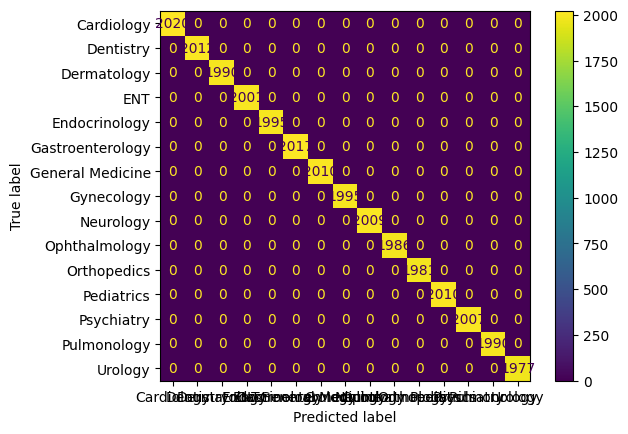

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

plt.show()